In [16]:
import pandas as pd

# We use 'on_bad_lines' and 'skiprows' to bypass the ARFF header text
# In this file, the actual data starts after the '@data' tag
df = pd.read_csv('kidney_disease.csv', skiprows=145, header=None, on_bad_lines='skip')

# Manually naming the columns since we skipped the header
df.columns = [
    'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
    'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn',
    'dm', 'cad', 'appet', 'pe', 'ane', 'classification'
]

print("Data loaded correctly! Here are the actual medical values:")
df.head()

Data loaded correctly! Here are the actual medical values:


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48,80,1.020,1,0,?,normal,notpresent,notpresent,121,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7,50,1.020,4,0,?,normal,notpresent,notpresent,?,...,38,6000,?,no,no,no,good,no,no,ckd
2,62,80,1.010,2,3,normal,normal,notpresent,notpresent,423,...,31,7500,?,no,yes,no,poor,no,yes,ckd
3,48,70,1.005,4,0,normal,abnormal,present,notpresent,117,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51,80,1.010,2,0,normal,normal,notpresent,notpresent,106,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [20]:
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer

# 1. Replace '?' and '\t?' with actual 'NaN' (Not a Number) so Python understands they are empty
df = df.replace('?', np.nan)
df = df.replace('\t?', np.nan) # Added to handle tab-prefixed question marks

# 2. Convert text categories to numbers (Encoding)
# This is a critical step for KNN
mapping = {
    "normal": 0, "abnormal": 1,
    "yes": 1, "no": 0,
    "good": 1, "poor": 0,
    "ckd": 1, "notckd": 0,
    "present": 1, "notpresent": 0
}
df_numeric = df.replace(mapping)

# Convert all columns to numeric, coercing errors to NaN
for col in df_numeric.columns:
    df_numeric[col] = pd.to_numeric(df_numeric[col], errors='coerce')

# 3. Apply KNN Imputation
# Instead of deleting patients with '?', we use their 5 nearest neighbors to estimate the value
imputer = KNNImputer(n_neighbors=5)
df_final = pd.DataFrame(imputer.fit_transform(df_numeric), columns=df.columns)

print("Data is now 100% numeric and missing values are filled!")
df_final.head()

Data is now 100% numeric and missing values are filled!


/tmp/ipykernel_9050/2015122455.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_numeric = df.replace(mapping)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,0.2,0.0,0.0,0.0,121.0,...,44.0,7800.0,5.20,1.0,1.0,0.0,1.0,0.0,0.0,1.0
1,7.0,50.0,1.020,4.0,0.0,0.4,0.0,0.0,0.0,113.0,...,38.0,6000.0,4.96,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,62.0,80.0,1.010,2.0,3.0,0.0,0.0,0.0,0.0,423.0,...,31.0,7500.0,3.80,0.0,1.0,0.0,0.0,0.0,1.0,1.0
3,48.0,70.0,1.005,4.0,0.0,0.0,1.0,1.0,0.0,117.0,...,32.0,6700.0,3.90,1.0,0.0,0.0,0.0,1.0,1.0,1.0
4,51.0,80.0,1.010,2.0,0.0,0.0,0.0,0.0,0.0,106.0,...,35.0,7300.0,4.60,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Separate Features (X) from the Result (y)
X = df_final.drop('classification', axis=1)
y = df_final['classification']

# 2. Split into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scaling (CRITICAL for KNN)
# Since 'age' can be 80 and 'sg' is 1.02, we must scale them to the same range
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Run the KNN Algorithm
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# 5. Check the results
predictions = knn.predict(X_test)
print(f"Project Accuracy: {accuracy_score(y_test, predictions) * 100:.2f}%")
print("\nDetailed Medical Report:")
print(classification_report(y_test, predictions))

Project Accuracy: 97.50%

Detailed Medical Report:
              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97        29
         1.0       1.00      0.96      0.98        51

    accuracy                           0.97        80
   macro avg       0.97      0.98      0.97        80
weighted avg       0.98      0.97      0.98        80



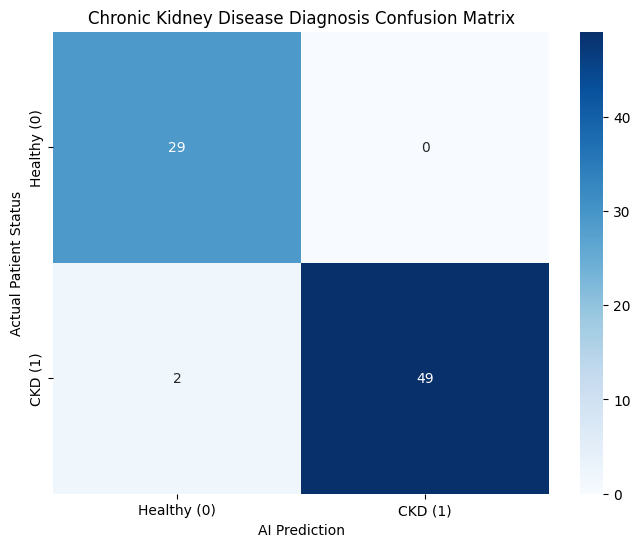

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create the matrix
cm = confusion_matrix(y_test, predictions)

# Plot it
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy (0)', 'CKD (1)'],
            yticklabels=['Healthy (0)', 'CKD (1)'])
plt.ylabel('Actual Patient Status')
plt.xlabel('AI Prediction')
plt.title('Chronic Kidney Disease Diagnosis Confusion Matrix')
plt.show()

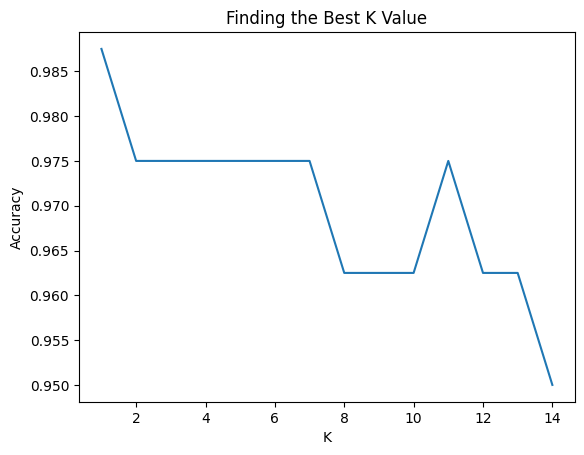

In [23]:
scores = []
for k in range(1, 15):
    test_knn = KNeighborsClassifier(n_neighbors=k)
    test_knn.fit(X_train, y_train)
    scores.append(test_knn.score(X_test, y_test))

plt.plot(range(1, 15), scores)
plt.title('Finding the Best K Value')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.show()

In [24]:
import joblib

# Save the model
joblib.dump(knn, 'ckd_model.pkl')

# Save the scaler (very important!)
joblib.dump(scaler, 'scaler.pkl')

print("Files saved! Download 'ckd_model.pkl' and 'scaler.pkl' from the sidebar folder.")

Files saved! Download 'ckd_model.pkl' and 'scaler.pkl' from the sidebar folder.
